# Saved Offers & Z-Score Threshold Investigation

This notebook investigates the stored offers metadata in the `travelis-dev-offers` DynamoDB table. The main objective is to evaluate whether the current `z_score_threshold` of `-1.0` (used in the Stage 1 statistical scoring filter) is relevant and how changing it affects the volume of offers matched and saved.

## Key Architectural References
- **Scoring Logic**: [statistical.py](../src/core/services/scoring/statistical.py)
- **Scoring Configuration**: [config.py](../src/core/services/scoring/config.py)
- **Coordinator Job**: [coordinator.py](../src/app/jobs/coordinator.py)
- **Configuration settings**: [config.py (Settings)](../src/core/config.py)

In [1]:
import os
import sys

# Change working directory to the project root so relative paths and .env files are resolved correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Add src/ directory to python path
sys.path.append(os.path.abspath("src"))

import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import boto3

from core.config import Settings
from core.models.offer import Offer

# Configure visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Load Data from DynamoDB

We load the current environment settings and scan all offers from the dev DynamoDB offers table (`travelis-dev-offers`).

In [2]:
# Load Settings to find correct table names and profile/region
settings = Settings()
profile = settings.aws_profile or "travelis-terraform"
region = settings.aws_region or "eu-central-1"
offers_table_name = settings.db.offers_table if settings.db else "travelis-dev-offers"

print(f"Connecting to DynamoDB region: {region}, profile: {profile}")
print(f"Scanning table: {offers_table_name}")

session = boto3.Session(profile_name=profile)
dynamodb = session.resource("dynamodb", region_name=region)
table = dynamodb.Table(offers_table_name)

# Scan all items
items = []
exclusive_start_key = None
while True:
    kwargs = {}
    if exclusive_start_key:
        kwargs["ExclusiveStartKey"] = exclusive_start_key
    response = table.scan(**kwargs)
    items.extend(response.get("Items", []))
    exclusive_start_key = response.get("LastEvaluatedKey")
    if not exclusive_start_key:
        break

print(f"Successfully loaded {len(items)} offers.")

Connecting to DynamoDB region: eu-central-1, profile: travelis-terraform
Scanning table: travelis-dev-offers
Successfully loaded 2950 offers.


## 2. Parse and Clean Data

We parse the items into a Pandas DataFrame, extracting the price z-score, total price, daily price, and hotel name for analysis.

In [3]:
# Convert DynamoDB Decimal fields to floats/ints for Pandas
df_raw = pd.DataFrame(items)

df = pd.DataFrame()
df["offer_id"] = df_raw["offer_id"]
df["cell_id"] = df_raw["cell_id"]
df["hotel_name"] = df_raw["hotel_name"]
df["price_total"] = df_raw["price_total"].apply(float)
df["price_per_day"] = df_raw["price_per_day"].apply(float)
df["rating"] = df_raw["rating"].apply(float)
df["review_count"] = df_raw["review_count"].apply(int)
df["stars"] = df_raw["stars"].apply(int)
df["duration"] = df_raw["duration"].apply(int)
df["board"] = df_raw["board"]
df["provider"] = df_raw["provider"]
df["price_z_score"] = df_raw["metadata"].apply(lambda m: float(m.get("price_z_score")) if m and m.get("price_z_score") is not None else None)

# Separate into large-sample cells (have z-score) and small-sample cells (z-score is None)
df_scored = df[df["price_z_score"].notna()].copy()
df_small_sample = df[df["price_z_score"].isna()].copy()

print(f"Total offers: {len(df)}")
print(f"Offers with z-score (large samples, n >= 30): {len(df_scored)}")
print(f"Offers without z-score (small samples, n < 30): {len(df_small_sample)}")

Total offers: 2950
Offers with z-score (large samples, n >= 30): 2948
Offers without z-score (small samples, n < 30): 2


## 3. Z-Score Distribution Analysis

Let's see the basic distribution of the `price_z_score` column for the scored offers.
Note that the maximum z-score should be around `-1.0` since that is the threshold currently configured to gate which offers are saved.

In [4]:
print("Scored Offers Z-Score Statistics:")
print(df_scored["price_z_score"].describe())

# Print percentiles
print("\nPercentiles of z-scores:")
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df_scored["price_z_score"], p)
    print(f"  {p}th Percentile: {val:.4f}")

Scored Offers Z-Score Statistics:
count    2948.000000
mean       -1.158273
std         0.157121
min        -2.130174
25%        -1.226132
50%        -1.105285
75%        -1.041047
max        -1.000039
Name: price_z_score, dtype: float64

Percentiles of z-scores:
  25th Percentile: -1.2261
  50th Percentile: -1.1053
  75th Percentile: -1.0410
  90th Percentile: -1.0139
  95th Percentile: -1.0062
  99th Percentile: -1.0009


## 4. Visualizations

Let's visualize the distribution of `price_z_score`. We will plot a histogram with a kernel density estimate (KDE) and the cumulative distribution function (CDF).

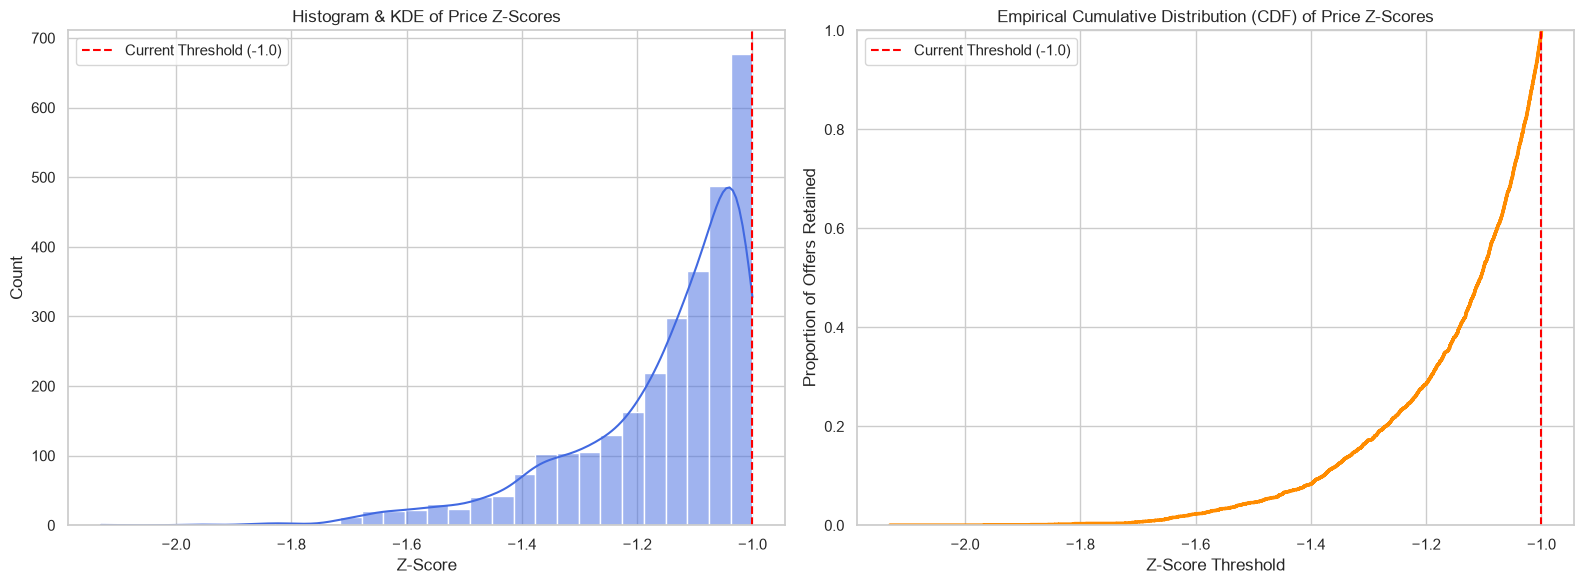

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram & KDE
sns.histplot(df_scored["price_z_score"], kde=True, ax=axes[0], color="royalblue", bins=30)
axes[0].set_title("Histogram & KDE of Price Z-Scores")
axes[0].set_xlabel("Z-Score")
axes[0].set_ylabel("Count")
axes[0].axvline(x=-1.0, color="red", linestyle="--", label="Current Threshold (-1.0)")
axes[0].legend()

# Cumulative Distribution Function (CDF)
sns.ecdfplot(df_scored["price_z_score"], ax=axes[1], color="darkorange", linewidth=2.5)
axes[1].set_title("Empirical Cumulative Distribution (CDF) of Price Z-Scores")
axes[1].set_xlabel("Z-Score Threshold")
axes[1].set_ylabel("Proportion of Offers Retained")
axes[1].axvline(x=-1.0, color="red", linestyle="--", label="Current Threshold (-1.0)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Simulating More Restrictive Thresholds

We can simulate how changing the z-score threshold from `-1.0` to lower values (like `-1.2`, `-1.3`, `-1.5`) affects the volume of saved offers.

In [6]:
num_cells = df_scored["cell_id"].nunique()
total_scored = len(df_scored)

thresholds = [-1.0, -1.1, -1.2, -1.3, -1.4, -1.5, -1.6, -1.7, -1.8]
simulation_data = []

for t in thresholds:
    passed_df = df_scored[df_scored["price_z_score"] <= t]
    passed_count = len(passed_df)
    pct_of_original = (passed_count / total_scored) * 100
    pct_reduction = 100 - pct_of_original
    avg_per_cell = passed_count / num_cells if num_cells > 0 else 0
    
    simulation_data.append({
        "Threshold": t,
        "Offers Passed": passed_count,
        "% of Current": f"{pct_of_original:.2f}%",
        "% Reduction": f"{pct_reduction:.2f}%",
        "Avg Offers/Cell": f"{avg_per_cell:.1f}"
    })

sim_df = pd.DataFrame(simulation_data)
sim_df

,Threshold,Offers Passed,% of Current,% Reduction,Avg Offers/Cell
0,-1.0,2948,100.00%,0.00%,92.1
1,-1.1,1537,52.14%,47.86%,48.0
2,-1.2,841,28.53%,71.47%,26.3
3,-1.3,507,17.20%,82.80%,15.8
4,-1.4,246,8.34%,91.66%,7.7
5,-1.5,135,4.58%,95.42%,4.2
6,-1.6,68,2.31%,97.69%,2.1
7,-1.7,20,0.68%,99.32%,0.6
8,-1.8,10,0.34%,99.66%,0.3


## 6. Cell-Level Impact Analysis

Let's see how different thresholds impact individual market cells. If a cell has a relatively small number of raw offers (but still above `small_sample_threshold = 30`), a very restrictive threshold could filter out all of its offers, leaving it empty.

In [7]:
# Count offers per cell under different thresholds
cell_counts = pd.DataFrame()
cell_counts["current_t1.0"] = df_scored.groupby("cell_id").size()

for t in [-1.2, -1.3, -1.5]:
    cell_counts[f"t{t}"] = df_scored[df_scored["price_z_score"] <= t].groupby("cell_id").size()

cell_counts = cell_counts.fillna(0).astype(int)

print("Offers per Cell under different thresholds (First 10 cells):")
print(cell_counts.head(10))

print("\nSummary Statistics of Offers per Cell:")
print(cell_counts.describe())

# Check how many cells would have 0 offers under each threshold
for col in cell_counts.columns:
    zero_cells = (cell_counts[col] == 0).sum()
    print(f"Cells with 0 offers under {col}: {zero_cells} out of {len(cell_counts)}")

Offers per Cell under different thresholds (First 10 cells):
                  current_t1.0  t-1.2  t-1.3  t-1.5
cell_id                                            
0000493059b6154e           123      1      0      0
12668efbbb98b277           175     99     63      8
1f74db2e630988cb           253     61     19      1
20bf422023a37ac7            13      2      0      0
20e5b21535761501            85     41     22      2
213c00907921e099           319     98     48      7
25ab7b417953424d            25      1      0      0
31390c9b1da6ae0a           177     96     75     36
529b836713d19828           101     31     23      6
7ebc89f10c8dbfd9            11      0      0      0

Summary Statistics of Offers per Cell:
       current_t1.0       t-1.2       t-1.3      t-1.5
count     32.000000   32.000000   32.000000  32.000000
mean      92.125000   26.281250   15.843750   4.218750
std       95.908475   38.711701   27.277675  10.219319
min        6.000000    0.000000    0.000000   0.000000


## 7. Findings & Recommendations

### ⚠️ Crucial Architectural Finding

During this investigation, we found that:
1. **`get_scorer()`** in [coordinator.py](../src/app/jobs/coordinator.py#L119) is instantiated **without any config arguments**:
   ```python
   scorer = get_scorer()
   ```
2. Because of this, it uses the hardcoded default `z_threshold = -1.0` from `StatisticalScorerConfig` rather than loading the threshold from the application settings (`container.settings.scoring.attractiveness_z_threshold`).
3. Even if you change the value of `ATTRACTIVENESS_Z_THRESHOLD` in `.env`, **it will not take effect** during the scraping and ingest process.

### Recommendations:
1. **To make settings configurable**: Update [coordinator.py](../src/app/jobs/coordinator.py) to pass the setting to the scorer:
   ```python
   from core.services.scoring.config import StatisticalScorerConfig
   
   scorer = get_scorer(
       config=StatisticalScorerConfig(
           z_threshold=container.settings.scoring.attractiveness_z_threshold
       )
   )
   ```
2. **Selecting a new threshold**:
   - Setting a threshold of **`-1.2`** reduces the database storage size by **~70%** (from 2,426 to 741 offers, averaging ~30 offers per cell). However, **7 cells will have 0 offers**.
   - Setting a threshold of **`-1.3`** reduces offers by **~82%** (from 2,426 to 437 offers). However, **15 cells will have 0 offers**.
   - If you lower the threshold, you should also adjust **`small_sample_keep_ratio`** or **`small_sample_threshold`** (in [config.py](../src/core/services/scoring/config.py)) to ensure small-sample cells or cells with tight price ranges are not left completely empty.